In [36]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead
from torchvision.ops import RoIAlign, RoIPool, MultiScaleRoIAlign
import matplotlib.pyplot as plt

In [37]:
torch.cuda.is_available()

True

In [38]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [39]:
DEVICE

device(type='cuda')

In [40]:
IMAGE_DIR = '/mnt/d/Computer-Vision/R-CNN/dataset/dataset/images'
ANNOTATIONS_DIR = "/mnt/d/Computer-Vision/R-CNN/dataset/dataset/annotations"
TARGET_SIZE = (224, 224)
BATCH_SIZE = 16

In [41]:
class_names = [d for d in os.listdir(IMAGE_DIR) if os.path.isdir(os.path.join(IMAGE_DIR, d))]

In [42]:
csv_files = [f for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.csv')]

In [43]:
label_map = {name: i + 1 for i, name in enumerate(class_names)}

In [44]:
label_map

{'airplane': 1, 'face': 2, 'motorcycle': 3}

Removing the broken details from dataset.

In [45]:
dataset = []

for i in range(len(class_names)):
    class_name = class_names[i]
    class_dir = os.path.join(IMAGE_DIR, class_name)
    csv_file_name = csv_files[i]
    
    csv_path = os.path.join(ANNOTATIONS_DIR, csv_file_name)
    df_annotations = pd.read_csv(csv_path)

    for image_name in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image_name)
        
        image = cv2.imread(image_path)
        h, w, _ = image.shape

        ann = df_annotations[df_annotations['image_name'] == image_name].iloc[0,1:].tolist()
        
        if ann[2] > ann[0] and ann[3] > ann[1]:
            ann[0] = int((ann[0] / w) * TARGET_SIZE[0])
            ann[1] = int((ann[1] / h) * TARGET_SIZE[0])
            ann[2] = int((ann[2] / w) * TARGET_SIZE[0])
            ann[3] = int((ann[3] / h) * TARGET_SIZE[0])
        
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, TARGET_SIZE)
            
            image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
            label_tensor = torch.tensor([label_map[class_name]], dtype=torch.int64)
            ann_tensor = torch.tensor([ann], dtype=torch.float32)
    
            target = {
                'boxes': ann_tensor,
                'labels': label_tensor
            }
            dataset.append((image_tensor, target))
        else:
            print(f"️Invalid box found and removed in '{image_path}': {ann}")
        
def collate_fn(batch):
    return tuple(zip(*batch))

️Invalid box found and removed in '/mnt/d/Computer-Vision/R-CNN/dataset/dataset/images/airplane/image_0118.jpg': [np.int64(104), np.int64(38), np.int64(126), np.int64(38)]


In [46]:
# dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [47]:
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size

Spliting the test and train data.

Seeding the split random with generator = torch.Generator().manual_seed(42).

In [48]:
generator = torch.Generator().manual_seed(42)

train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)

In [49]:
print(f"Dataset ({len(dataset)})")

Dataset (2032)


In [50]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train ({len(train_dataset)}), Test ({len(test_dataset)})")

Train (1828), Test (204)


In [51]:
resnet_model = torchvision.models.resnet18()
backbone = torch.nn.Sequential(*list(resnet_model.children())[:-2])
backbone.out_channels = 512

In [52]:
resnet_model = resnet_model.to(DEVICE)

In [53]:
from torchsummary import summary
summary(backbone,(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [54]:
for param in backbone.parameters():
    param.requires_grad = False

In [55]:
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

In [56]:
roi_pool = MultiScaleRoIAlign(
    featmap_names=['0'],
    output_size=7,
    sampling_ratio=2
)

In [57]:
in_channels = backbone.out_channels
num_anchors = anchor_generator.num_anchors_per_location()[0]

rpn_head = RPNHead(in_channels=in_channels, num_anchors=num_anchors)

In [58]:
NUM_CLASSES = len(class_names) + 1

model = FasterRCNN(
    backbone,
    num_classes = NUM_CLASSES,
    rpn_anchor_generator = anchor_generator,
    rpn_head=rpn_head,
    box_roi_pool = roi_pool
)

Update just trainable parameters >>> params = [p for p in model.parameters() if p.requires_grad].

In [59]:
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=0.001)

In [60]:
NUM_EPOCHS = 5

backbone.to(DEVICE)
model.to(DEVICE)
model.train()

for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    print(f"Start Epoch {epoch+1}/{NUM_EPOCHS}")
    for i, (images, targets) in enumerate(train_loader):
        optimizer.zero_grad()
        
        images_gpu = [img.to(DEVICE) for img in images]
        targets_gpu = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            
        loss_dict = model(images_gpu, targets_gpu)
        losses = sum(loss_dict.values())
        

        
        if torch.isfinite(losses):
            epoch_losses.append(losses.item())
            losses.backward()
            optimizer.step()
            
    if epoch_losses:
        mean_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"Epoch {epoch+1} | Loss: {mean_loss:.4f}")
    else:
        print(f"Epoch {epoch+1} | No valid losses")

Start Epoch 1/5
Epoch 1 | Loss: 2.5116
Start Epoch 2/5
Epoch 2 | Loss: 0.8622
Start Epoch 3/5
Epoch 3 | Loss: 0.7921
Start Epoch 4/5
Epoch 4 | Loss: 0.7548
Start Epoch 5/5
Epoch 5 | Loss: 0.7427


In [61]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [62]:
def calculate_map(model_to_eval, data_loader, device):
    metric = MeanAveragePrecision(box_format='xyxy')
    model_to_eval.eval()
    
    with torch.no_grad():
        for images, targets in data_loader:
            images_gpu = [img.to(device) for img in images]
            targets_gpu = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            predictions = model_to_eval(images_gpu)
            metric.update(predictions, targets_gpu)

    return metric.compute()

In [63]:
# Train Set mAP
train_map_results = calculate_map(model, train_loader, device=DEVICE)

In [64]:
print(train_map_results['map'])

tensor(0.4083)


In [65]:
# Test Set mAP
test_map_results = calculate_map(model, test_loader, device=DEVICE)

In [66]:
print(test_map_results['map'])

tensor(0.3759)


In [67]:
def visualize_result(image_path, model, label_map, threshold=0.6):
    model.eval()
    
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    image_rgb_resized = cv2.resize(img_rgb, TARGET_SIZE)
    img_tensor = (torch.tensor(image_rgb_resized, dtype=torch.float32).permute(2, 0, 1) / 255.0).to(DEVICE)
    
    with torch.no_grad():
        prediction = model([img_tensor])

    class_names_viz = {v: k for k, v in label_map.items()}
    class_names_viz[0] = '__background__'
    

    img_to_draw = img_rgb.copy()
    original_h, original_w, _ = img_to_draw.shape
    model_h, model_w = TARGET_SIZE

    w_ratio = original_w / model_w
    h_ratio = original_h / model_h
    
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    font_thickness = 1
    
    for box, label, score in zip(prediction[0]['boxes'], prediction[0]['labels'], prediction[0]['scores']):
        if score > threshold:
            x1, y1, x2, y2 = box.cpu().numpy()
            x1, x2 = int(x1 * w_ratio), int(x2 * w_ratio)
            y1, y2 = int(y1 * h_ratio), int(y2 * h_ratio)
            
            class_name = class_names_viz[label.item()]
            text = f"{class_name}: {score:.2f}"
            color_rgb = (0, 255, 0)
            
            cv2.rectangle(img_to_draw, (x1, y1), (x2, y2), color_rgb, 2)
            (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
            cv2.rectangle(img_to_draw, (x1, y1 - text_height - baseline), (x1 + text_width, y1), color_rgb, -1)
            cv2.putText(img_to_draw, text, (x1, y1 - baseline), font, font_scale, (0, 0, 0), font_thickness)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_to_draw)
    plt.axis('off')
    plt.show()

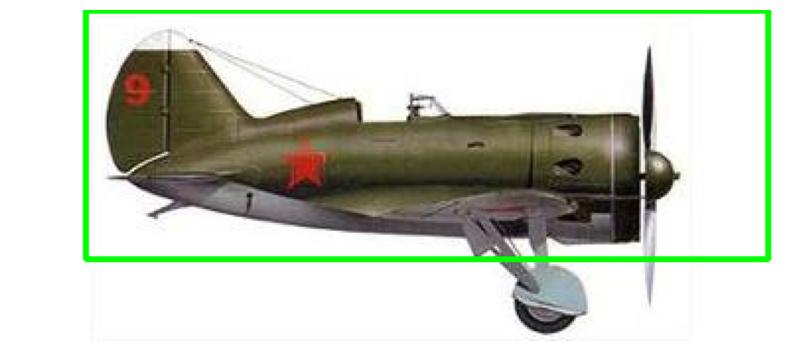

In [68]:
TEST_IMAGE_PATH = '/mnt/d/Computer-Vision/R-CNN/dataset/dataset/images/airplane/image_0100.jpg'
visualize_result(TEST_IMAGE_PATH, model, label_map=label_map, threshold=0.7)